# Randles-Ševčík Analysis: Scan Rates, Kinetics, and Analytical Benchmarks

This tutorial demonstrates how to use **Soft Potato** to analyze Cyclic Voltammetry (CV) data and benchmark numerical simulations against analytical theory.

We investigate two key fundamental phenomena in electrochemistry:
1. **Scan Rate Dependency ($i_p$ vs. $\sqrt{\nu}$)**: Evaluating reversible electron transfer across multiple scan rates and verifying the linear Randles-Ševčík relationship.
2. **Kinetic Effects at Fixed Scan Rate (Varying $k_0$)**: Exploring the transition from reversible (Nernstian) to quasi-reversible and totally irreversible kinetics by varying the standard rate constant $k_0$ and comparing with reversible and irreversible Randles-Ševčík limits.

All simulations adhere to the **IUPAC sign convention**:
* **Cathodic (reduction) current is negative** ($i < 0$)
* **Anodic (oxidation) current is positive** ($i > 0$)

## 1. Environment Verification & Installation

Check if `softpotato` is installed in the current environment; if not, install it automatically.

In [1]:
try:
    import softpotato as sp
    print(f"Soft Potato {sp.__version__} is already installed.")
except ImportError:
    import sys, subprocess
    print("Installing softpotato...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "softpotato"])
    import softpotato as sp
    print(f"Soft Potato {sp.__version__} installed successfully.")

Soft Potato 3.0.0rc1 is already installed.


## 2. Theory: The Randles-Ševčík Equations

### 2.1 Reversible Electron Transfer
For a reversible, diffusion-controlled reduction ($O + n e^- \rightleftharpoons R$) at $298.15\text{ K}$, the peak current magnitude is given by the **Randles-Ševčík equation**:

$$i_p^{\text{rev}} = 0.4463 \, n F A c_{\text{bulk}} \sqrt{\frac{n F \nu D}{R T}}$$

Under the IUPAC convention, the cathodic peak current is:

$$i_{pc} = -0.4463 \, n F A c_{\text{bulk}} \sqrt{\frac{n F \nu D}{R T}}$$

Key diagnostic criteria for a reversible process:
* The peak current $|i_p|$ is directly proportional to $\sqrt{\nu}$.
* The peak potential separation is independent of scan rate: $\Delta E_p = |E_{pa} - E_{pc}| \approx \frac{59\text{ mV}}{n}$ at $25^\circ\text{C}$.
* The peak current ratio is unity: $|i_{pa} / i_{pc}| = 1$.

### 2.2 Irreversible Electron Transfer
When electron transfer kinetics are slow compared to mass transport, the reaction becomes irreversible, yielding:

$$i_p^{\text{irrev}} = 0.4958 \, n F A c_{\text{bulk}} \sqrt{D} \left( \frac{\alpha F \nu}{R T} \right)^{1/2}$$

For $\alpha = 0.5$, $i_p^{\text{irrev}} \approx 0.785 \times i_p^{\text{rev}}$, reflecting lower peak current and broader peak profiles.

### 2.3 Electrochemical Reversibility & Nicholson's Parameter
The kinetic regime is governed by Nicholson's dimensionless parameter $\Psi$:

$$\Psi = \frac{k_0}{\sqrt{\pi D \frac{n F \nu}{R T}}}$$

* $\Psi > 7$: **Reversible** (Nernstian equilibrium maintained at surface)
* $0.001 < \Psi < 7$: **Quasi-reversible** (finite kinetics cause $\Delta E_p > 59\text{ mV}$)
* $\Psi < 0.001$: **Totally irreversible** (overpotential-dominated, no reverse peak on reverse sweep)

## 3. Part 1: Simulations at Different Scan Rates ($i_p$ vs. $\sqrt{\nu}$)

We configure a reversible system ($k_0 = 1.0\text{ cm/s}$) and simulate CVs across four scan rates: $\nu \in [0.05, 0.10, 0.20, 0.40]\text{ V/s}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import softpotato as sp
from softpotato.analytical import randles_sevcik, randles_sevcik_irreversible, nicholson_psi

# Electrochemical parameters (CGS units)
n = 1
area = 0.0707          # cm^2 (e.g. 3 mm diameter disc electrode)
D = 1.0e-5             # cm^2/s
c_bulk = 1.0e-6        # mol/cm^3 (1.0 mM)
alpha = 0.5
k0_rev = 1.0           # cm/s (fast reversible kinetics)

# Spatial grid and electrode geometry
grid = sp.geometry.UniformGrid(x_max=0.10, nodes=800)
electrode = sp.geometry.PlanarElectrode(area=area, grid=grid)

# Scan rates to evaluate
scan_rates = [0.05, 0.10, 0.20, 0.40]  # V/s
sim_results_rates = {}

print("Running scan rate simulations...")
for v in scan_rates:
    # Set up species and reaction mechanism
    spec_O = sp.core.Species(name="O", D=D, c_bulk=c_bulk)
    spec_R = sp.core.Species(name="R", D=D, c_bulk=0.0)
    bv = sp.kinetics.ButlerVolmer(k0=k0_rev, alpha=alpha)
    rxn = sp.core.ElectrochemicalReaction(
        reactants=[spec_O], products=[spec_R], n_electrons=n, E0=0.0, kinetics=bv
    )
    mech = sp.core.Mechanism([rxn])
    
    # Setup CV technique from 0.3 V to -0.3 V and back
    cv = sp.techniques.CyclicVoltammetry(
        E_initial=0.3, E_vertex1=-0.3, scan_rate=v, dE=0.002, n_sweeps=2
    )
    solver = sp.simulate.Solver(mech, electrode, cv, method="EFD", auto_substep=True)
    sim_results_rates[v] = solver.run()
    print(f"  Done: v = {v:.2f} V/s")

Running scan rate simulations...


/tmp/ipykernel_17592/3805167294.py:38: UserWarning: CFL stability condition exceeded (lambda = 25.536 > 0.5). Automatically sub-stepping with 57 internal steps per technique point.
  sim_results_rates[v] = solver.run()


  Done: v = 0.05 V/s


/tmp/ipykernel_17592/3805167294.py:38: UserWarning: CFL stability condition exceeded (lambda = 12.768 > 0.5). Automatically sub-stepping with 29 internal steps per technique point.
  sim_results_rates[v] = solver.run()


  Done: v = 0.10 V/s
  Done: v = 0.20 V/s


/tmp/ipykernel_17592/3805167294.py:38: UserWarning: CFL stability condition exceeded (lambda = 6.384 > 0.5). Automatically sub-stepping with 15 internal steps per technique point.
  sim_results_rates[v] = solver.run()
/tmp/ipykernel_17592/3805167294.py:38: UserWarning: CFL stability condition exceeded (lambda = 3.192 > 0.5). Automatically sub-stepping with 8 internal steps per technique point.
  sim_results_rates[v] = solver.run()


  Done: v = 0.40 V/s


### 3.1 Overlay of Cyclic Voltammograms at Different Scan Rates

Notice how current magnitude expands with $\sqrt{\nu}$, while the peak potentials ($E_{pc}$ and $E_{pa}$) remain stationary at constant $\Delta E_p \approx 60\text{ mV}$.

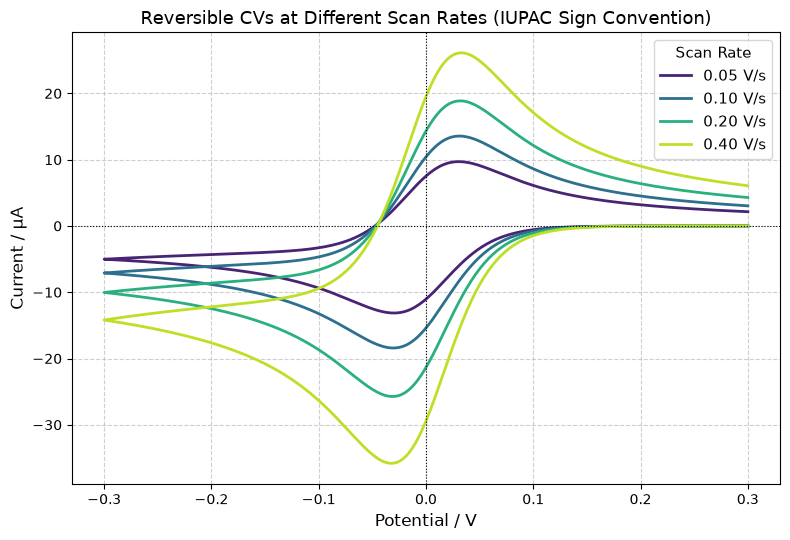

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(scan_rates)))

for v, color in zip(scan_rates, colors):
    res = sim_results_rates[v]
    ax.plot(res.potential, res.current * 1e6, lw=2, color=color, label=f"{v:.2f} V/s")

ax.set_xlabel("Potential / V", fontsize=12)
ax.set_ylabel("Current / µA", fontsize=12)
ax.set_title("Reversible CVs at Different Scan Rates (IUPAC Sign Convention)", fontsize=13)
ax.axhline(0, color="black", lw=0.8, linestyle=":")
ax.axvline(0, color="black", lw=0.8, linestyle=":")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Scan Rate", fontsize=11, title_fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Randles-Ševčík Diagnostic Plot: $i_p$ vs. $\sqrt{\nu}$

We extract simulated cathodic peak currents $i_{pc}$ and anodic peak currents $i_{pa}$, and plot them against the analytical Randles-Ševčík response.

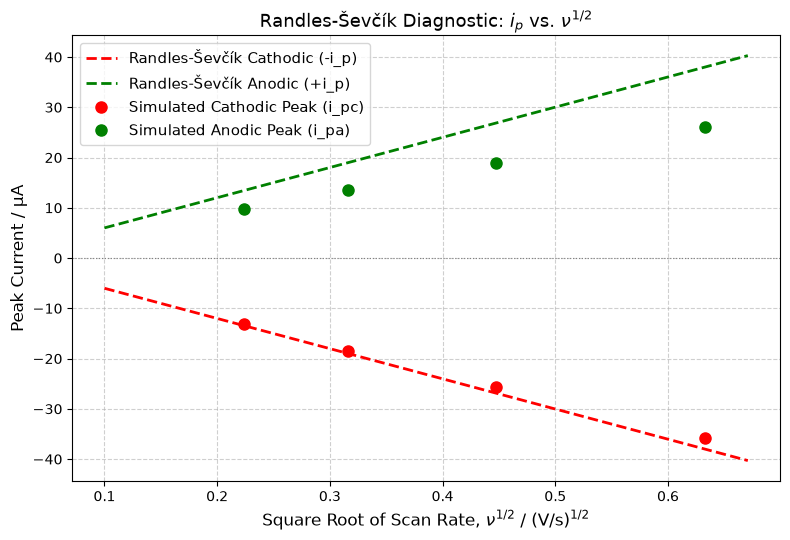

v (V/s)    v^1/2      Sim i_pc (µA)    Ana i_pc (µA)    Error (%) 
--------------------------------------------------------------
0.05       0.224      -13.14           -13.43           2.18      
0.10       0.316      -18.42           -18.99           3.04      
0.20       0.447      -25.73           -26.86           4.21      
0.40       0.632      -35.81           -37.99           5.72      


In [4]:
# Extract simulated peaks
sqrt_v = np.sqrt(scan_rates)
i_pc_sim = []
i_pa_sim = []

for v in scan_rates:
    res = sim_results_rates[v]
    sweep1_len = len(res.potential) // 2
    # Reduction is negative, oxidation is positive
    i_pc_sim.append(np.min(res.current[:sweep1_len]))
    i_pa_sim.append(np.max(res.current[sweep1_len:]))

i_pc_sim = np.array(i_pc_sim)
i_pa_sim = np.array(i_pa_sim)

# Continuous analytical Randles-Ševčík curves
v_fine = np.linspace(0.01, 0.45, 100)
sqrt_v_fine = np.sqrt(v_fine)
i_p_analytical = randles_sevcik(n=n, area=area, D=D, c_bulk=c_bulk, scan_rate=v_fine)

# Plot peak currents vs sqrt(v)
fig, ax = plt.subplots(figsize=(8, 5.5))

# Analytical lines
ax.plot(sqrt_v_fine, -i_p_analytical * 1e6, "r--", lw=2, label="Randles-Ševčík Cathodic (-i_p)")
ax.plot(sqrt_v_fine, i_p_analytical * 1e6, "g--", lw=2, label="Randles-Ševčík Anodic (+i_p)")

# Simulated data points
ax.plot(sqrt_v, i_pc_sim * 1e6, "ro", markersize=8, label="Simulated Cathodic Peak (i_pc)")
ax.plot(sqrt_v, i_pa_sim * 1e6, "go", markersize=8, label="Simulated Anodic Peak (i_pa)")

ax.axhline(0, color="gray", linestyle=":", lw=0.8)
ax.set_xlabel(r"Square Root of Scan Rate, $\nu^{1/2}$ / (V/s)$^{1/2}$", fontsize=12)
ax.set_ylabel("Peak Current / µA", fontsize=12)
ax.set_title(r"Randles-Ševčík Diagnostic: $i_p$ vs. $\nu^{1/2}$", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'v (V/s)':<10} {'v^1/2':<10} {'Sim i_pc (µA)':<16} {'Ana i_pc (µA)':<16} {'Error (%)':<10}")
print("-" * 62)
for v, sv, ipc in zip(scan_rates, sqrt_v, i_pc_sim):
    iana = -randles_sevcik(n=n, area=area, D=D, c_bulk=c_bulk, scan_rate=v)
    err = abs(ipc - iana) / abs(iana) * 100
    print(f"{v:<10.2f} {sv:<10.3f} {ipc*1e6:<16.2f} {iana*1e6:<16.2f} {err:<10.2f}")

## 4. Part 2: Kinetic Effects at Fixed Scan Rate (Varying $k_0$)

Next, we hold the scan rate constant at $\nu = 0.10\text{ V/s}$ and vary the standard heterogeneous rate constant $k_0$ across four orders of magnitude:

$$k_0 \in [1.0, 10^{-2}, 10^{-3}, 10^{-4}]\text{ cm/s}$$

This spans the full electrochemical spectrum from **reversible** (Nernstian) to **quasi-reversible** and **totally irreversible**.

In [5]:
v_fixed = 0.10  # V/s
k0_values = [1.0, 1e-2, 1e-3, 1e-4]  # cm/s
sim_results_kinetics = {}
psi_values = {}

print(f"Running kinetic simulations at v = {v_fixed:.2f} V/s...")
for k0 in k0_values:
    spec_O = sp.core.Species(name="O", D=D, c_bulk=c_bulk)
    spec_R = sp.core.Species(name="R", D=D, c_bulk=0.0)
    bv = sp.kinetics.ButlerVolmer(k0=k0, alpha=alpha)
    rxn = sp.core.ElectrochemicalReaction(
        reactants=[spec_O], products=[spec_R], n_electrons=n, E0=0.0, kinetics=bv
    )
    mech = sp.core.Mechanism([rxn])
    
    # Wider potential window (-0.4 V to 0.4 V) to capture shifted peaks of slow kinetics
    cv = sp.techniques.CyclicVoltammetry(
        E_initial=0.4, E_vertex1=-0.4, scan_rate=v_fixed, dE=0.002, n_sweeps=2
    )
    solver = sp.simulate.Solver(mech, electrode, cv, method="EFD", auto_substep=True)
    sim_results_kinetics[k0] = solver.run()
    psi_values[k0] = float(nicholson_psi(k0=k0, D_O=D, scan_rate=v_fixed, n=n, alpha=alpha))
    print(f"  Done: k0 = {k0:.0e} cm/s (Psi = {psi_values[k0]:.3f})")

Running kinetic simulations at v = 0.10 V/s...


/tmp/ipykernel_17592/3500858285.py:21: UserWarning: CFL stability condition exceeded (lambda = 12.768 > 0.5). Automatically sub-stepping with 29 internal steps per technique point.
  sim_results_kinetics[k0] = solver.run()


  Done: k0 = 1e+00 cm/s (Psi = 90.433)
  Done: k0 = 1e-02 cm/s (Psi = 0.904)
  Done: k0 = 1e-03 cm/s (Psi = 0.090)
  Done: k0 = 1e-04 cm/s (Psi = 0.009)


### 4.1 Cyclic Voltammograms as a Function of Electron Transfer Kinetics

We overlay the simulated CVs with the **Reversible Randles-Ševčík** and **Irreversible Randles-Ševčík** bounds.

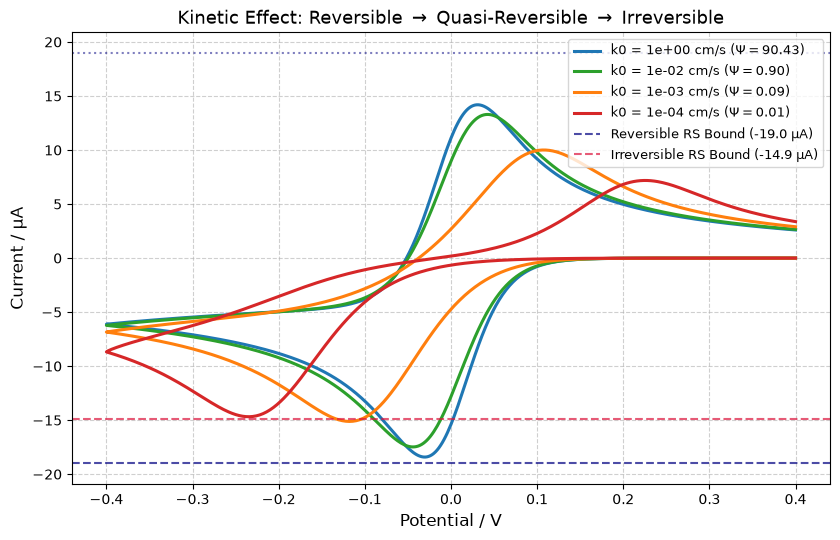

In [6]:
# Analytical reference limits at v = 0.10 V/s
i_p_rev = float(randles_sevcik(n=n, area=area, D=D, c_bulk=c_bulk, scan_rate=v_fixed))
i_p_irrev = float(randles_sevcik_irreversible(n=n, area=area, D=D, c_bulk=c_bulk, scan_rate=v_fixed, alpha=alpha))

fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Plot CV curves
palette = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
for k0, color in zip(k0_values, palette):
    res = sim_results_kinetics[k0]
    psi = psi_values[k0]
    label = rf"k0 = {k0:.0e} cm/s ($\Psi={psi:.2f}$)"
    ax.plot(res.potential, res.current * 1e6, lw=2.2, color=color, label=label)

# Analytical bounds (IUPAC: cathodic is negative, anodic is positive)
ax.axhline(-i_p_rev * 1e6, color="navy", linestyle="--", alpha=0.7, label=f"Reversible RS Bound ({-i_p_rev*1e6:.1f} µA)")
ax.axhline(i_p_rev * 1e6, color="navy", linestyle=":", alpha=0.5)
ax.axhline(-i_p_irrev * 1e6, color="crimson", linestyle="--", alpha=0.7, label=f"Irreversible RS Bound ({-i_p_irrev*1e6:.1f} µA)")

ax.set_xlabel("Potential / V", fontsize=12)
ax.set_ylabel("Current / µA", fontsize=12)
ax.set_title("Kinetic Effect: Reversible $\\rightarrow$ Quasi-Reversible $\\rightarrow$ Irreversible", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=9.5, loc="upper right")
plt.tight_layout()
plt.show()

### 4.2 Diagnostic Trends: Peak Separation $\Delta E_p$ and Peak Current $|i_{pc}|$ vs. $\log_{10}(k_0)$

The two plots below illustrate the fundamental diagnostics used by electrochemists:
1. **Peak Potential Separation ($\Delta E_p$)**: At high $k_0$, $\Delta E_p \approx 59\text{ mV}$. As kinetics become sluggish, $\Delta E_p$ expands dramatically.
2. **Cathodic Peak Current ($|i_{pc}|$)**: Decreases smoothly from the reversible Randles-Ševčík limit down to the irreversible Randles-Ševčík limit.

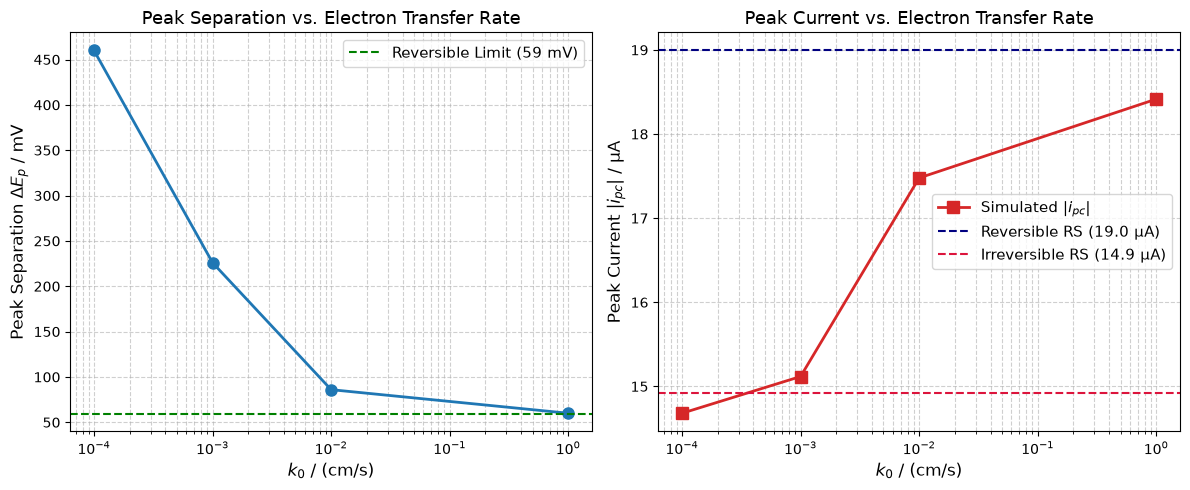

k0 (cm/s)    Psi        Delta Ep (mV)    |i_pc| (µA)    Kinetic Regime
----------------------------------------------------------------------
1e+00        90.433     60.0             18.42          Reversible
1e-02        0.904      86.0             17.48          Quasi-reversible
1e-03        0.090      226.0            15.12          Quasi-reversible
1e-04        0.009      460.0            14.68          Irreversible


In [7]:
delta_Eps = []
i_pcs = []

for k0 in k0_values:
    res = sim_results_kinetics[k0]
    sweep1_len = len(res.potential) // 2
    idx_c = np.argmin(res.current[:sweep1_len])
    idx_a = sweep1_len + np.argmax(res.current[sweep1_len:])
    
    E_pc = res.potential[idx_c]
    E_pa = res.potential[idx_a]
    dEp = abs(E_pa - E_pc) * 1000  # mV
    
    delta_Eps.append(dEp)
    i_pcs.append(abs(res.current[idx_c]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Delta Ep vs log10(k0)
ax1.plot(k0_values, delta_Eps, "o-", color="#1f77b4", lw=2, markersize=8)
ax1.axhline(59.0, color="green", linestyle="--", label="Reversible Limit (59 mV)")
ax1.set_xscale("log")
ax1.set_xlabel(r"$k_0$ / (cm/s)", fontsize=12)
ax1.set_ylabel(r"Peak Separation $\Delta E_p$ / mV", fontsize=12)
ax1.set_title(r"Peak Separation vs. Electron Transfer Rate", fontsize=13)
ax1.grid(True, which="both", linestyle="--", alpha=0.6)
ax1.legend(fontsize=11)

# 2. |i_pc| vs log10(k0)
ax2.plot(k0_values, np.array(i_pcs) * 1e6, "s-", color="#d62728", lw=2, markersize=8, label="Simulated $|i_{pc}|$" )
ax2.axhline(i_p_rev * 1e6, color="navy", linestyle="--", label=f"Reversible RS ({i_p_rev*1e6:.1f} µA)")
ax2.axhline(i_p_irrev * 1e6, color="crimson", linestyle="--", label=f"Irreversible RS ({i_p_irrev*1e6:.1f} µA)")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k_0$ / (cm/s)", fontsize=12)
ax2.set_ylabel(r"Peak Current $|i_{pc}|$ / µA", fontsize=12)
ax2.set_title(r"Peak Current vs. Electron Transfer Rate", fontsize=13)
ax2.grid(True, which="both", linestyle="--", alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Summary table
print(f"{'k0 (cm/s)':<12} {'Psi':<10} {'Delta Ep (mV)':<16} {'|i_pc| (µA)':<14} {'Kinetic Regime'}")
print("-" * 70)
for k0, dEp, ipc in zip(k0_values, delta_Eps, i_pcs):
    psi = psi_values[k0]
    regime = "Reversible" if psi > 7 else ("Quasi-reversible" if psi > 0.05 else "Irreversible")
    print(f"{k0:<12.0e} {psi:<10.3f} {dEp:<16.1f} {ipc*1e6:<14.2f} {regime}")

## 5. Summary & Key Takeaways

1. **Reversible Systems**:
   * Peak currents scale strictly with $\sqrt{\nu}$ according to the classical Randles-Ševčík equation.
   * Peak potential separation is constant at $\Delta E_p \approx 59\text{ mV}$ regardless of scan rate.
2. **Kinetic Transitions**:
   * Decreasing $k_0$ causes the system to transition from reversible ($\Psi > 7$) to quasi-reversible and irreversible ($\Psi < 0.05$).
   * Sluggish electron transfer manifests as peak broadening, increased $\Delta E_p$, and attenuation of the peak current from the reversible Randles-Ševčík limit down to the irreversible limit ($i_p^{\text{irrev}} = 0.785 \times i_p^{\text{rev}}$ for $\alpha=0.5$).
3. **Soft Potato Workflow**:
   * The combination of `softpotato.simulate.Solver` and `softpotato.analytical.randles_sevcik` enables rapid, rigorous benchmarking of electrochemical experiments and mechanisms.